<a href="https://colab.research.google.com/github/MsTejasviSingh/Cancer-Genomics/blob/main/02_RNAseq_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Gene Count Data

The FeatureCounts output file contains the number of sequencing reads assigned to each gene across all RNA-seq samples.

In this step, the count matrix is imported into Python using pandas so that it can be explored and analyzed.

Rows represent genes, while columns represent samples.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = '/content/drive/MyDrive/RNAseq_Project'

bam_path = f"{project_path}/Sorted_BAM"
gtf_path = f"{project_path}/chrX_data/genes/chrX.gtf"

print("Project:", project_path)
print("BAM Folder:", bam_path)
print("GTF Folder:", gtf_path)


Project: /content/drive/MyDrive/RNAseq_Project
BAM Folder: /content/drive/MyDrive/RNAseq_Project/Sorted_BAM
GTF Folder: /content/drive/MyDrive/RNAseq_Project/chrX_data/genes/chrX.gtf


In [ ]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project/Sorted_BAM" | head
!ls -lh "/content/drive/MyDrive/RNAseq_Project/chrX_data/genes"

total 1.5G
-rw------- 1 root root 144M Aug 22 16:45 ERR188044_chrX.sorted.bam
-rw------- 1 root root 163K Aug 22 16:54 ERR188044_chrX.sorted.bam.bai
-rw------- 1 root root 139M Aug 22 16:45 ERR188104_chrX.sorted.bam
-rw------- 1 root root 161K Aug 22 16:54 ERR188104_chrX.sorted.bam.bai
-rw------- 1 root root 185M Aug 22 16:45 ERR188234_chrX.sorted.bam
-rw------- 1 root root 167K Aug 22 16:54 ERR188234_chrX.sorted.bam.bai
-rw------- 1 root root 101M Aug 22 16:45 ERR188245_chrX.sorted.bam
-rw------- 1 root root 146K Aug 22 16:54 ERR188245_chrX.sorted.bam.bai
-rw------- 1 root root 113M Aug 22 16:46 ERR188257_chrX.sorted.bam
total 6.5M
-rw------- 1 root root 6.5M Aug 20 16:55 chrX.gtf


In [ ]:
!apt-get install -y subread

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  subread
0 upgraded, 1 newly installed, 0 to remove and 4 not upgraded.
Need to get 565 kB of archives.
After this operation, 1,928 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 subread amd64 2.0.3+dfsg-1 [565 kB]
Fetched 565 kB in 0s (5,077 kB/s)
Selecting previously unselected package subread.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../subread_2.0.3+dfsg-1_amd64.deb ...
Unpacking subread (2.0.3+dfsg-1) ...
Setting up subread (2.0.3+dfsg-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!featureCounts -v


featureCounts v2.0.3



In [ ]:
!mkdir "/content/drive/MyDrive/RNAseq_Project/FeatureCounts"

In [ ]:
!featureCounts \
-T 2\
-p \
-a "/content/drive/MyDrive/RNAseq_Project/chrX_data/genes/chrX.gtf"\
-o "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt"\
/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/*.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 12 BAM files                                     ||
||                                                                            ||
||                           ERR188044_chrX.sorted.bam                        ||
||                           ERR188104_chrX.sorted.bam                        ||
||                           ERR188234_chrX.sorted.bam           

In [ ]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project" | grep FeatureCounts

drwx------ 2 root root 4.0K Aug 23 14:37 FeatureCounts
-rw------- 1 root root 576K Aug 23 14:45 FeatureCountsgene_counts.txt
-rw------- 1 root root 1.8K Aug 23 14:45 FeatureCountsgene_counts.txt.summary
-rw------- 1 root root 1.8K Aug 23 14:41 FeatureCounts.summary


# Exploring the Count Matrix

Before performing any analysis, it is important to inspect the dataset.

The dimensions of the matrix are checked to determine the number of genes and samples. Column names are also examined to verify that all RNA-seq samples were imported correctly.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt.summary" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCounts.summary" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

In [5]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

total 580K
-rw------- 1 root root 576K Aug 23 14:45 FeatureCountsgene_counts.txt
-rw------- 1 root root 1.8K Aug 23 14:45 FeatureCountsgene_counts.txt.summary
-rw------- 1 root root 1.8K Aug 23 14:41 FeatureCounts.summary


In [8]:
import pandas as pd

counts = pd.read_csv("/content/drive/MyDrive/RNAseq_Project/FeatureCounts/FeatureCountsgene_counts.txt", sep="\t",comment="#")

counts.head()


,Geneid,Chr,Start,End,Strand,Length,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188044_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188104_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188234_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188245_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188257_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188273_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188337_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188383_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188401_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188428_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188454_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR204916_chrX.sorted.bam
0,NM_033031,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;c...,50284540;50285127;50288780;50294863;50308505;5...,50284616;50285259;50288887;50294993;50311496;5...,+;+;+;+;+;+;+;+;+;+;+;+,4511,26,31,6,6,6,6,14,8,20,5,29,14
1,NM_033670,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX,50284540;50285127;50288780;50342202;50346652;5...,50284616;50285259;50288887;50342339;50346807;5...,+;+;+;+;+;+;+;+,1199,0,0,0,0,0,0,0,0,0,0,0,0
2,NM_144969,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;c...,75368427;75379120;75417087;75421864;75424652;7...,75372945;75379198;75417190;75421990;75424784;7...,-;-;-;-;-;-;-;-;-;-;-;-,6043,0,0,0,0,0,0,0,0,0,0,0,0
3,NM_001168362,chrX;chrX;chrX;chrX;chrX,91835461;91876781;92387735;92468299;92618264,91836044;91879273;92387933;92468322;92623229,+;+;+;+;+,8266,0,0,0,0,0,0,0,0,0,0,0,0
4,NM_001168361,chrX;chrX;chrX;chrX;chrX;chrX;chrX,91835461;91876781;92201375;92263114;92287967;9...,91836044;91879273;92201455;92263143;92288002;9...,+;+;+;+;+;+;+,8214,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
counts.shape

(2082, 18)

In [12]:
counts.columns.tolist()

['Geneid',
 'Chr',
 'Start',
 'End',
 'Strand',
 'Length',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188044_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188104_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188234_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188245_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188257_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188273_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188337_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188383_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188401_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188428_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188454_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR204916_chrX.sorted

# Cleaning Sample Names

FeatureCounts uses the full BAM file path as the column name for each sample.

To make downstream analysis easier, the file paths are replaced with simple sample IDs such as ERR188044 and ERR188104.

In [13]:
from google import colab
clean_counts = counts.copy()

#Replacing column names
clean_counts.columns = [
    col.split("/")[-1].replace("_chrX.sorted.bam","")

if ".bam" in col

#Otherwise column name unchanged
else col

for col in clean_counts.columns]

clean_counts.columns


Index(['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'ERR188044',
       'ERR188104', 'ERR188234', 'ERR188245', 'ERR188257', 'ERR188273',
       'ERR188337', 'ERR188383', 'ERR188401', 'ERR188428', 'ERR188454',
       'ERR204916'],
      dtype='object')

In [14]:
expression = clean_counts.drop(

columns = ["Chr","Start","End","Strand","Length"]

)

expression.head()

,Geneid,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,NM_033031,26,31,6,6,6,6,14,8,20,5,29,14
1,NM_033670,0,0,0,0,0,0,0,0,0,0,0,0
2,NM_144969,0,0,0,0,0,0,0,0,0,0,0,0
3,NM_001168362,0,0,0,0,0,0,0,0,0,0,0,0
4,NM_001168361,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
sample_data = expression.iloc[:,1:]

#Checking each sample, and is the sum equals to zero then gene is not expressed anywhere

zero_genes = (sample_data.sum(axis=1)==0)

zero_genes.sum()

np.int64(1302)

In [16]:
expression["Total_Count"] = sample_data.sum(axis=1)

#Sorting genes from highest to lowest counts
top_genes = expression.sort_values(
    by="Total_Count",
    ascending=False
)

top_genes[["Geneid", "Total_Count"]].head(10)

,Geneid,Total_Count
156,NM_021109,4224078
1266,NM_001007,1124980
386,NM_000291,1027681
1186,NM_002444,639628
654,NM_001636,465133
311,NM_031407,401957
798,NM_001415,253723
1578,NM_001152,253263
960,NM_006743,213387
1638,NM_018990,185776


# Loading Sample Metadata

The metadata file contains information about each RNA-seq sample, including biological sex and population group.

This information is required for downstream comparative analyses because it provides the biological context needed to interpret gene expression differences between samples.

In [17]:
pheno = pd.read_csv("/content/drive/MyDrive/RNAseq_Project/chrX_data/geuvadis_phenodata.csv")

pheno

,ids,sex,population
0,ERR188044,male,YRI
1,ERR188104,male,YRI
2,ERR188234,female,YRI
3,ERR188245,female,GBR
4,ERR188257,male,GBR
5,ERR188273,female,YRI
6,ERR188337,female,GBR
7,ERR188383,male,GBR
8,ERR188401,male,GBR
9,ERR188428,female,GBR


In [19]:
pheno.shape

(12, 3)

In [20]:
pheno.columns

Index(['ids', 'sex', 'population'], dtype='object')

# Evaluating Library Sizes

Library sizes provide an estimate of sequencing depth and help identify samples with unusually low or high numbers of assigned reads.

The samples in this dataset show variation in library size, ranging from approximately 0.6 million to 1.6 million assigned reads. Such variation is expected in RNA-seq experiments and will be accounted for during normalization.

In [21]:
# Only the sample columns
sample_counts = expression.iloc[:, 1:13]

# Total counts per sample
library_sizes = sample_counts.sum()

library_sizes

,0
ERR188044,1252066
ERR188104,1256650
ERR188234,1568219
ERR188245,829093
ERR188257,910134
ERR188273,594576
ERR188337,1145649
ERR188383,926556
ERR188401,1260627
ERR188428,830168


In [23]:
print(type(sample_counts))
print(sample_counts.shape)

sample_counts.head()

<class 'pandas.core.frame.DataFrame'>
(2082, 12)


,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,26,31,6,6,6,6,14,8,20,5,29,14
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2082,) and arg 1 with shape (2082, 12).

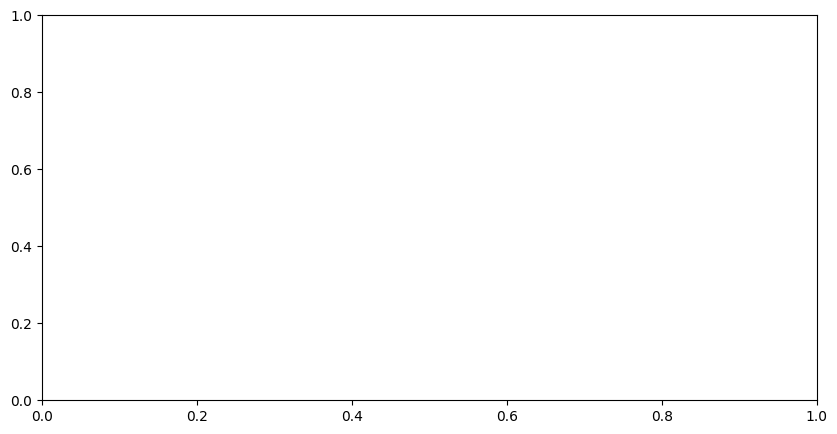

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# sample_counts.index = sample names (ERR188044, ERR188104,....)
# sample_counts.values = total reads assigned to genes
plt.bar(sample_counts.index, sample_counts.values)

plt.xlabel("Sample")

plt.ylabel("Total Counts")

plt.title("Total gene count per sample")

#Roatate sample names so they do not overlap
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()